In [1]:
from pathlib import Path

import numpy as np

In [2]:
DATASET_DIR = Path(r"")
IMU_ID = 1
IMU_FILENAME = f"imu_{IMU_ID:03d}.csv"
G_EARTH = 9.80665

In [3]:
def parse_csv(f: Path) -> np.ndarray:
    """
    读取CSV,返回imu数据。
    [0] - 时间戳
    [1,2,3] - 加速度xyz
    [4,5,6] - 陀螺仪xyz
    """
    data = np.genfromtxt(f, delimiter=',', skip_header=1, usecols=(1, 2, 3, 4, 5, 6, 7))
    return data.T


In [4]:
imu_data: list[np.ndarray] = []
for p in DATASET_DIR.iterdir():
    if not p.is_dir():
        continue
    file = p / IMU_FILENAME
    data = parse_csv(file)
    imu_data.append(data)

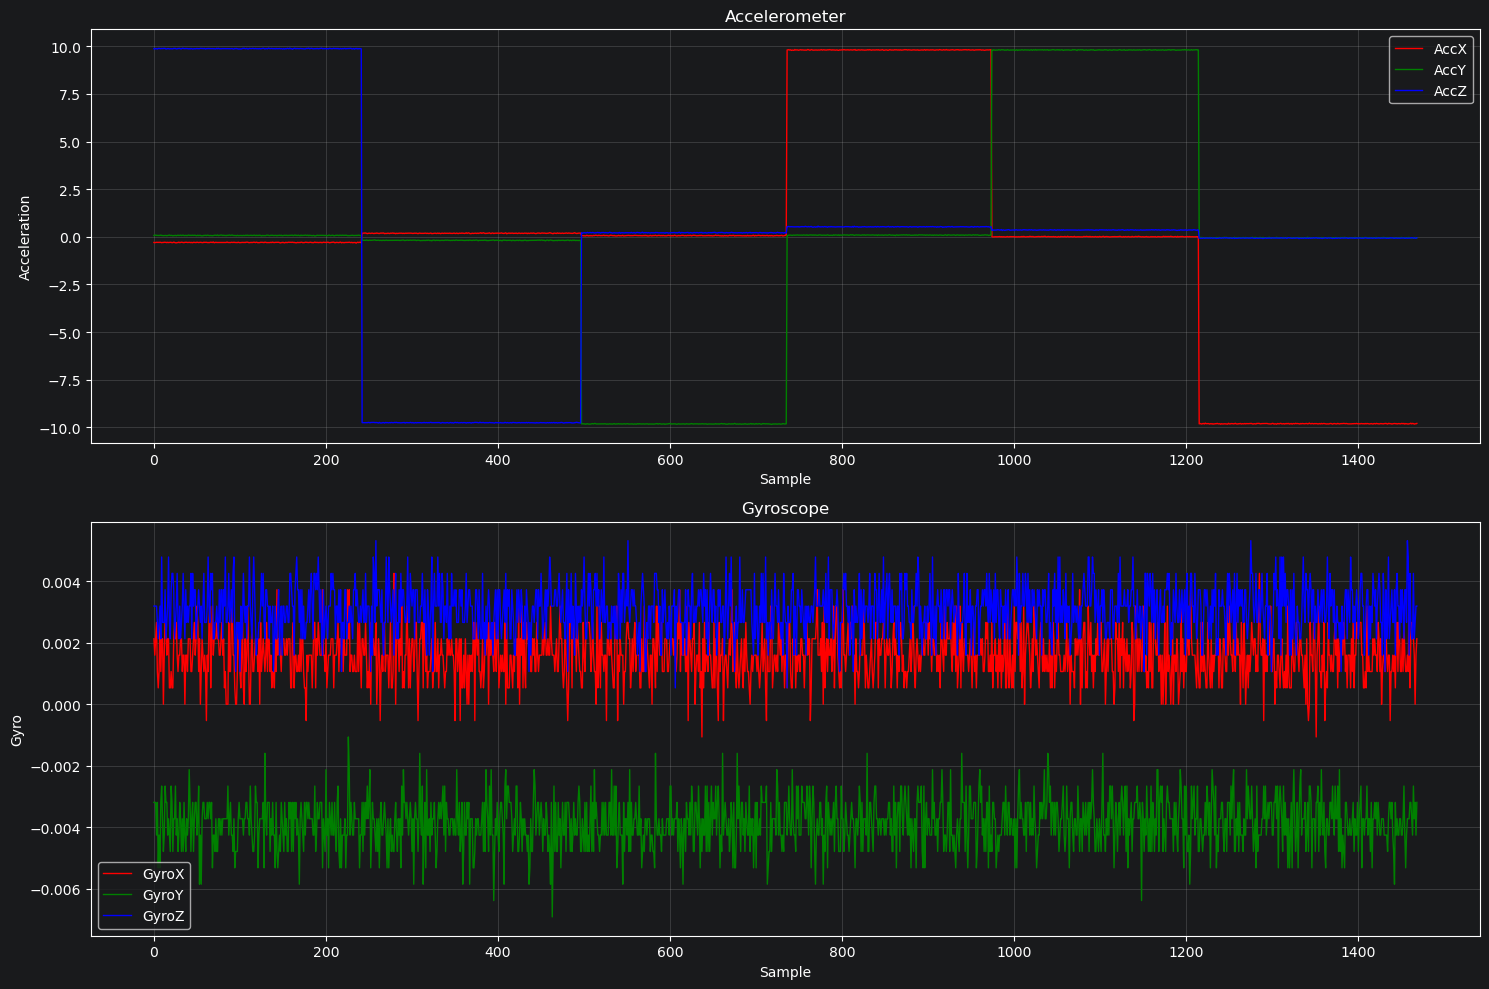

In [5]:
import matplotlib.pyplot as plt

# 按时间顺序拼接所有数据
all_data = np.hstack(imu_data)  # (7, total_samples)
acc = all_data[1:4]
gyro = all_data[4:7]

fig, axes = plt.subplots(2, 1, figsize=(15, 10))
acc_labels = ['AccX', 'AccY', 'AccZ']
gyro_labels = ['GyroX', 'GyroY', 'GyroZ']
colors = ['r', 'g', 'b']

# 画加速度计
for i in range(3):
    axes[0].plot(acc[i], label=acc_labels[i], color=colors[i], linewidth=1)
axes[0].set_xlabel('Sample')
axes[0].set_ylabel('Acceleration')
axes[0].set_title('Accelerometer')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 画陀螺仪
for i in range(3):
    axes[1].plot(gyro[i], label=gyro_labels[i], color=colors[i], linewidth=1)
axes[1].set_xlabel('Sample')
axes[1].set_ylabel('Gyro')
axes[1].set_title('Gyroscope')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


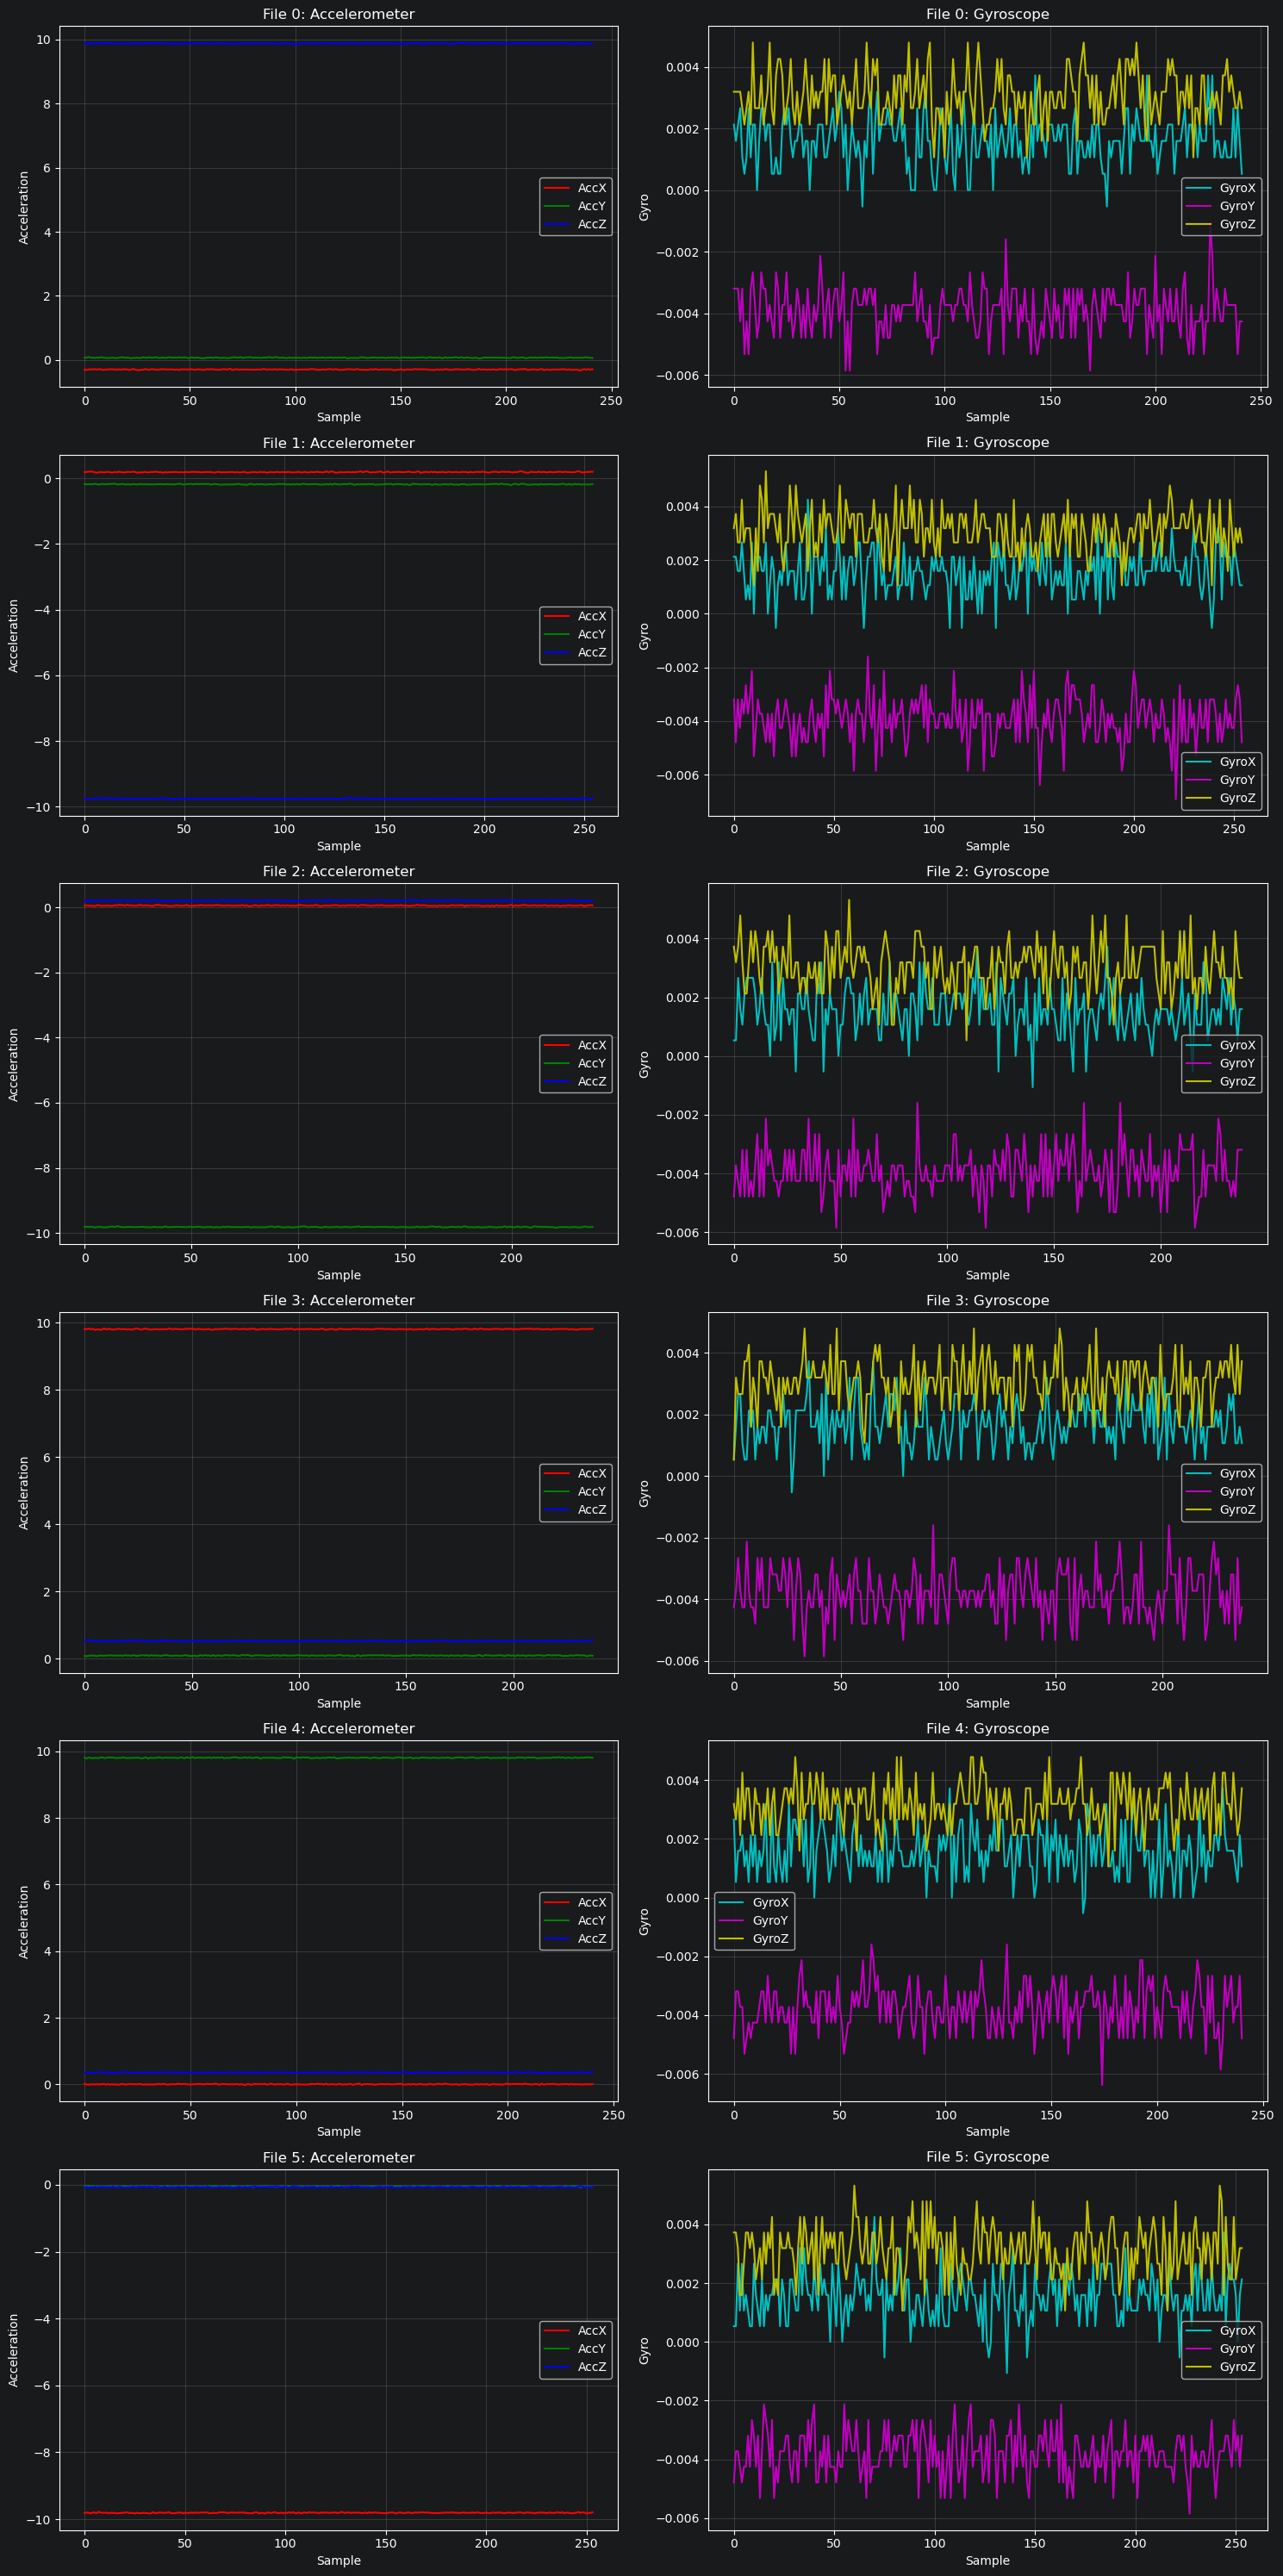

In [6]:
import matplotlib.pyplot as plt

# 按文件分别绘制每个文件的 ACC 和 Gyro
fig, axes = plt.subplots(len(imu_data), 2, figsize=(15, 5 * len(imu_data)))

if len(imu_data) == 1:
    axes = axes.reshape(1, -1)

for i, ax_row in enumerate(axes):
    data = imu_data[i]

    # 画加速度计
    ax_row[0].plot(data[1], label='AccX', color='r')
    ax_row[0].plot(data[2], label='AccY', color='g')
    ax_row[0].plot(data[3], label='AccZ', color='b')
    ax_row[0].set_xlabel('Sample')
    ax_row[0].set_ylabel('Acceleration')
    ax_row[0].set_title(f'File {i}: Accelerometer')
    ax_row[0].legend()
    ax_row[0].grid(True, alpha=0.3)

    # 画陀螺仪
    ax_row[1].plot(data[4], label='GyroX', color='c')
    ax_row[1].plot(data[5], label='GyroY', color='m')
    ax_row[1].plot(data[6], label='GyroZ', color='y')
    ax_row[1].set_xlabel('Sample')
    ax_row[1].set_ylabel('Gyro')
    ax_row[1].set_title(f'File {i}: Gyroscope')
    ax_row[1].legend()
    ax_row[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [7]:
def acc_mean(imu_data: list[np.ndarray]) -> np.ndarray:
    return np.array([data[1:4].mean(axis=1) for data in imu_data]).T


def matrix_from_theta(theta: np.ndarray):
    T = np.array([
        [1, -theta[0], +theta[1]],
        [0, 1, -theta[2]],
        [0, 0, 1],
    ])
    K = np.array([
        [theta[3], 0, 0],
        [0, theta[4], 0],
        [0, 0, theta[5]],
    ])
    b = theta[6:9].reshape(3, 1)
    return T, K, b


def acc_calibrated(acc_measure: np.ndarray, T: np.ndarray, K: np.ndarray, b: np.ndarray) -> np.ndarray:
    return (T @ K @ (acc_measure + b)).T


def acc_residual(theta_acc: np.ndarray, acc_mean: np.ndarray):
    """
    theta_acc = [alpha_yz, alpha_zy, alpha_zx, s^a_x, s^a_y, s^a_z, b^a_x, b^a_y, b^a_z]
    """
    T, K, b = matrix_from_theta(theta_acc)
    acc_calib = acc_calibrated(acc_mean, T, K, b)

    acc_norm_sq = np.sum(acc_calib ** 2, axis=1)
    return G_EARTH ** 2 - acc_norm_sq

In [8]:
from scipy.optimize import least_squares

theta_acc_init = np.zeros(9)
acc_m = acc_mean(imu_data)
result = least_squares(
    acc_residual,
    theta_acc_init,
    args=(acc_m,),
    method='trf',
    ftol=1e-10,
    xtol=1e-10,
    gtol=1e-10,
    max_nfev=10000,
)
print('cost:')
print(result.cost)
theta_acc = result.x

cost:
3.1684356172567345e-19


In [9]:
T, K, b = matrix_from_theta(theta_acc)
print("T:")
print(T)
print("K:")
print(K)
print("b:")
print(b)

T:
[[ 1.00000000e+00  9.98080585e-04 -3.30120381e-03]
 [ 0.00000000e+00  1.00000000e+00  1.27299304e-02]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]
K:
[[0.99928816 0.         0.        ]
 [0.         0.99890611 0.        ]
 [0.         0.         0.99832101]]
b:
[[-0.00480143]
 [ 0.00178641]
 [-0.06087532]]


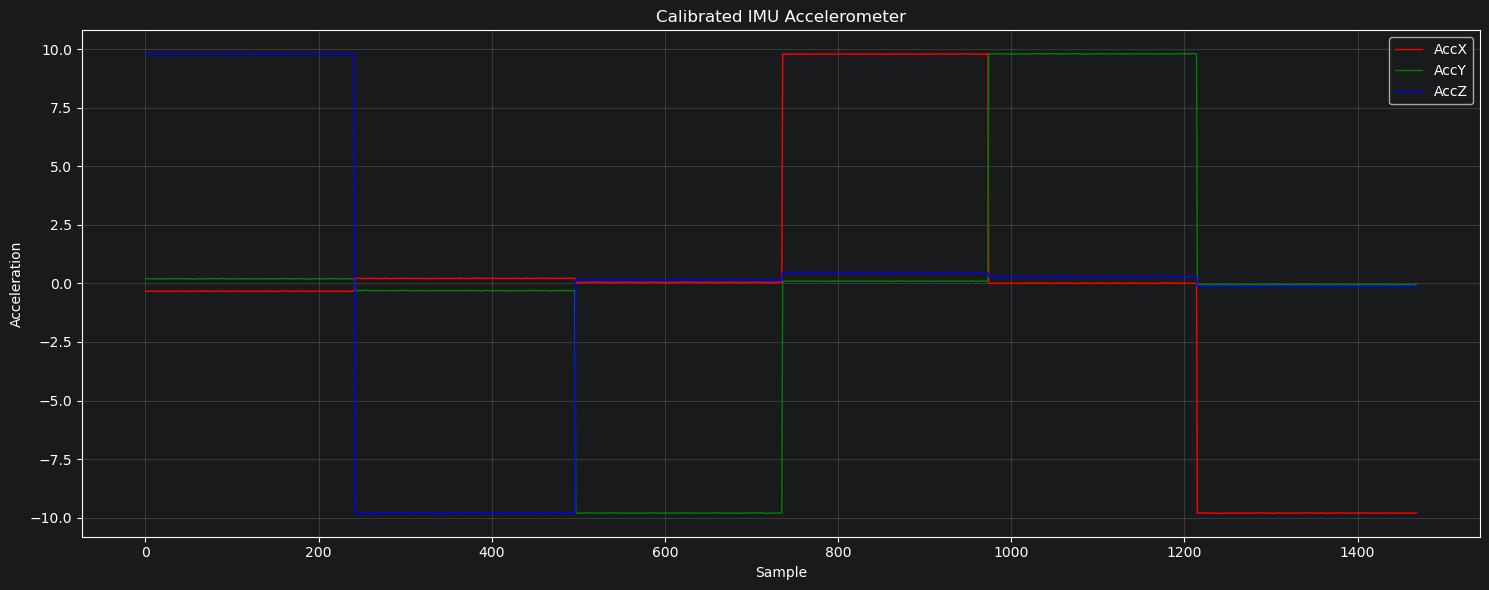

In [10]:
imu_data_acc_calibrated: list[np.ndarray] = []
for data in imu_data:
    calibrated = data.copy()
    calibrated[1:4] = acc_calibrated(data[1:4], T, K, b).T
    imu_data_acc_calibrated.append(calibrated)

all_data_acc_calibrated = np.hstack(imu_data_acc_calibrated)
acc_calibrated_all = all_data_acc_calibrated[1:4]

fig, ax = plt.subplots(figsize=(15, 6))
acc_labels = ['AccX', 'AccY', 'AccZ']
colors = ['r', 'g', 'b']

for i in range(3):
    ax.plot(acc_calibrated_all[i], label=acc_labels[i], color=colors[i], linewidth=1)

ax.set_xlabel('Sample')
ax.set_ylabel('Acceleration')
ax.set_title('Calibrated IMU Accelerometer')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


单步积分$\omega$:
$$f(q,t) = \dot{q} = \frac{1}{2}\Omega(\omega(t))q$$
$$
\Omega(\omega) = \begin{bmatrix}
0 & -\omega_x & -\omega_y & -\omega_z \\
\omega_x & 0 & \omega_z & -\omega_y \\
\omega_y & -\omega_z & 0 & \omega_x \\
\omega_z & \omega_y & -\omega_x & 0 \\
\end{bmatrix}
$$
计算：
$$L(\theta^{gyro}) = \sum_{k=2}^{M} ||u_{a,k} - u_{g,k}||$$
其中$u_{a,k}$为加速度计结果，$u_{g,k}$为从k-1时刻积分得到的预测加速度计结果，
$$\theta^{gyro} = \begin{bmatrix} \gamma_{yz} & \gamma_{zy} & \gamma_{xz} & \gamma_{zx} & \gamma_{xy} & \gamma_{yx} & s_x^g & s_y^g & s_z^g \end{bmatrix}$$
且
$$
T^g = \begin{bmatrix}
1 & -\gamma_{yz} & \gamma_{zy} \\
\gamma_{xz} & 1 & -\gamma_{zx} \\
-\gamma_{xy} & \gamma_{yx} & 1\\
\end{bmatrix}
$$
$$
K^g = \begin{bmatrix}
s_x^g & 0 & 0 \\
0 & s_y^g & 0  \\
0 & 0 & s_z^g  \\
\end{bmatrix}
$$
$$\omega^O = T^gK^g(\omega^S + b^g)$$
其中$b^g$直接从第一个测量结果的平均值得到

实现中 gyro 数据索引为 `data[4:7]`。

In [11]:
def omega_matrix(omega: np.ndarray) -> np.ndarray:
    wx, wy, wz = omega
    return np.array([
        [0.0, -wx, -wy, -wz],
        [wx, 0.0, wz, -wy],
        [wy, -wz, 0.0, wx],
        [wz, wy, -wx, 0.0],
    ])


def quat_derivative(q: np.ndarray, omega: np.ndarray) -> np.ndarray:
    return 0.5 * omega_matrix(omega) @ q


def normalize_quaternion(q: np.ndarray) -> np.ndarray:
    return q / np.linalg.norm(q)


def quaternion_to_rotation_matrix(q: np.ndarray) -> np.ndarray:
    q = normalize_quaternion(q)
    w, x, y, z = q
    return np.array([
        [1.0 - 2.0 * (y * y + z * z), 2.0 * (x * y - w * z), 2.0 * (x * z + w * y)],
        [2.0 * (x * y + w * z), 1.0 - 2.0 * (x * x + z * z), 2.0 * (y * z - w * x)],
        [2.0 * (x * z - w * y), 2.0 * (y * z + w * x), 1.0 - 2.0 * (x * x + y * y)],
    ])


def matrix_from_theta_gyro(theta: np.ndarray):
    T_g = np.array([
        [1.0, -theta[0], theta[1]],
        [theta[2], 1.0, -theta[3]],
        [-theta[4], theta[5], 1.0],
    ])
    K_g = np.diag(theta[6:9])
    return T_g, K_g


def gyro_bias_from_first_window(first_segment: np.ndarray) -> np.ndarray:
    return first_segment[4:7, :1].mean(axis=1, keepdims=True)


def gyro_calibrated(gyro_measure: np.ndarray, T_g: np.ndarray, K_g: np.ndarray, b_g: np.ndarray) -> np.ndarray:
    return T_g @ K_g @ (gyro_measure + b_g)


def rk4_step(q0: np.ndarray, omega_km1: np.ndarray, omega_k: np.ndarray, dt: float) -> np.ndarray:
    omega_mid = 0.5 * (omega_km1 + omega_k)

    k1 = quat_derivative(q0, omega_km1)
    k2 = quat_derivative(q0 + 0.5 * dt * k1, omega_mid)
    k3 = quat_derivative(q0 + 0.5 * dt * k2, omega_mid)
    k4 = quat_derivative(q0 + dt * k3, omega_k)

    q1 = q0 + (dt / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)
    return normalize_quaternion(q1)


def relative_quaternion_rk4(data: np.ndarray, theta_gyro: np.ndarray) -> np.ndarray:
    timestamps = data[0]
    gyro_raw = data[4:7]

    T_g, K_g = matrix_from_theta_gyro(theta_gyro)
    first_segment = imu_data_acc_calibrated[0]
    b_g = -gyro_bias_from_first_window(first_segment)
    gyro = gyro_calibrated(gyro_raw, T_g, K_g, b_g)

    delta_q = np.zeros((4, data.shape[1]))
    delta_q[:, 0] = np.array([1.0, 0.0, 0.0, 0.0])

    for k in range(1, data.shape[1]):
        dt = (timestamps[k] - timestamps[k - 1]) * 1e-6
        q0 = np.array([1.0, 0.0, 0.0, 0.0])
        delta_q[:, k] = rk4_step(q0, gyro[:, k - 1], gyro[:, k], dt)

    return delta_q


def gyro_residual_stats(data: np.ndarray, acc_jump_threshold: float = 0.5 * G_EARTH,
                        num_samples: int | None = None) -> dict:
    acc_calibrated = data[1:4]
    total_intervals = data.shape[1] - 1
    skipped = 0

    for k in range(1, data.shape[1]):
        if np.linalg.norm(acc_calibrated[:, k] - acc_calibrated[:, k - 1]) > acc_jump_threshold:
            skipped += 1

    if num_samples is None:
        num_samples = data.shape[1]

    return {
        'num_samples': num_samples,
        'total_intervals': total_intervals,
        'skipped_intervals': skipped,
        'kept_intervals': total_intervals - skipped,
        'all_skipped': skipped == total_intervals,
    }


def gyro_residual(theta_gyro: np.ndarray, data: np.ndarray, acc_jump_threshold: float = 0.5 * G_EARTH) -> np.ndarray:
    acc_calibrated = data[1:4]
    delta_q = relative_quaternion_rk4(data, theta_gyro)

    residuals = []
    for k in range(1, data.shape[1]):
        if np.linalg.norm(acc_calibrated[:, k] - acc_calibrated[:, k - 1]) > acc_jump_threshold:
            continue

        rotation_k = quaternion_to_rotation_matrix(delta_q[:, k])
        u_g_k = rotation_k @ acc_calibrated[:, k - 1]
        u_a_k = acc_calibrated[:, k]
        residuals.append(u_a_k - u_g_k)

    if not residuals:
        return np.zeros(3)

    return np.concatenate(residuals)


theta_gyro_init = np.array([
    0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
    1.0, 1.0, 1.0,
])

gyro_data_for_fit = all_data_acc_calibrated
result_gyro = least_squares(
    gyro_residual,
    theta_gyro_init,
    args=(gyro_data_for_fit,),
    method='trf',
    ftol=1e-10,
    xtol=1e-10,
    gtol=1e-10,
    max_nfev=10000,
)
theta_gyro = result_gyro.x
T_g, K_g = matrix_from_theta_gyro(theta_gyro)
first_segment = imu_data_acc_calibrated[0]
b_g = -gyro_bias_from_first_window(first_segment)

print('theta_gyro:')
print(theta_gyro)
print('T_g:')
print(T_g)
print('K_g:')
print(K_g)
print('b_g:')
print(b_g)
print('cost:')
print(result_gyro.cost)

residual_stats = gyro_residual_stats(
    gyro_data_for_fit,
    num_samples=len(imu_data_acc_calibrated),
)
print('residual_stats:')
print(residual_stats)
print('skipped == num_samples - 1:')
print(residual_stats['skipped_intervals'] == residual_stats['num_samples'] - 1)


theta_gyro:
[ 1.75799569e-01 -1.81228118e+00 -2.62854906e+02 -1.39530922e+00
 -1.86705713e+02  1.58743849e-01  5.20382606e-03 -2.72376290e+00
  1.59321316e+00]
T_g:
[[ 1.00000000e+00 -1.75799569e-01 -1.81228118e+00]
 [-2.62854906e+02  1.00000000e+00  1.39530922e+00]
 [ 1.86705713e+02  1.58743849e-01  1.00000000e+00]]
K_g:
[[ 0.00520383  0.          0.        ]
 [ 0.         -2.7237629   0.        ]
 [ 0.          0.          1.59321316]]
b_g:
[[-0.00212845]
 [ 0.00319268]
 [-0.00319268]]
cost:
0.3899297122300667
residual_stats:
{'num_samples': 6, 'total_intervals': 1468, 'skipped_intervals': 5, 'kept_intervals': 1463, 'all_skipped': False}
skipped == num_samples - 1:
True


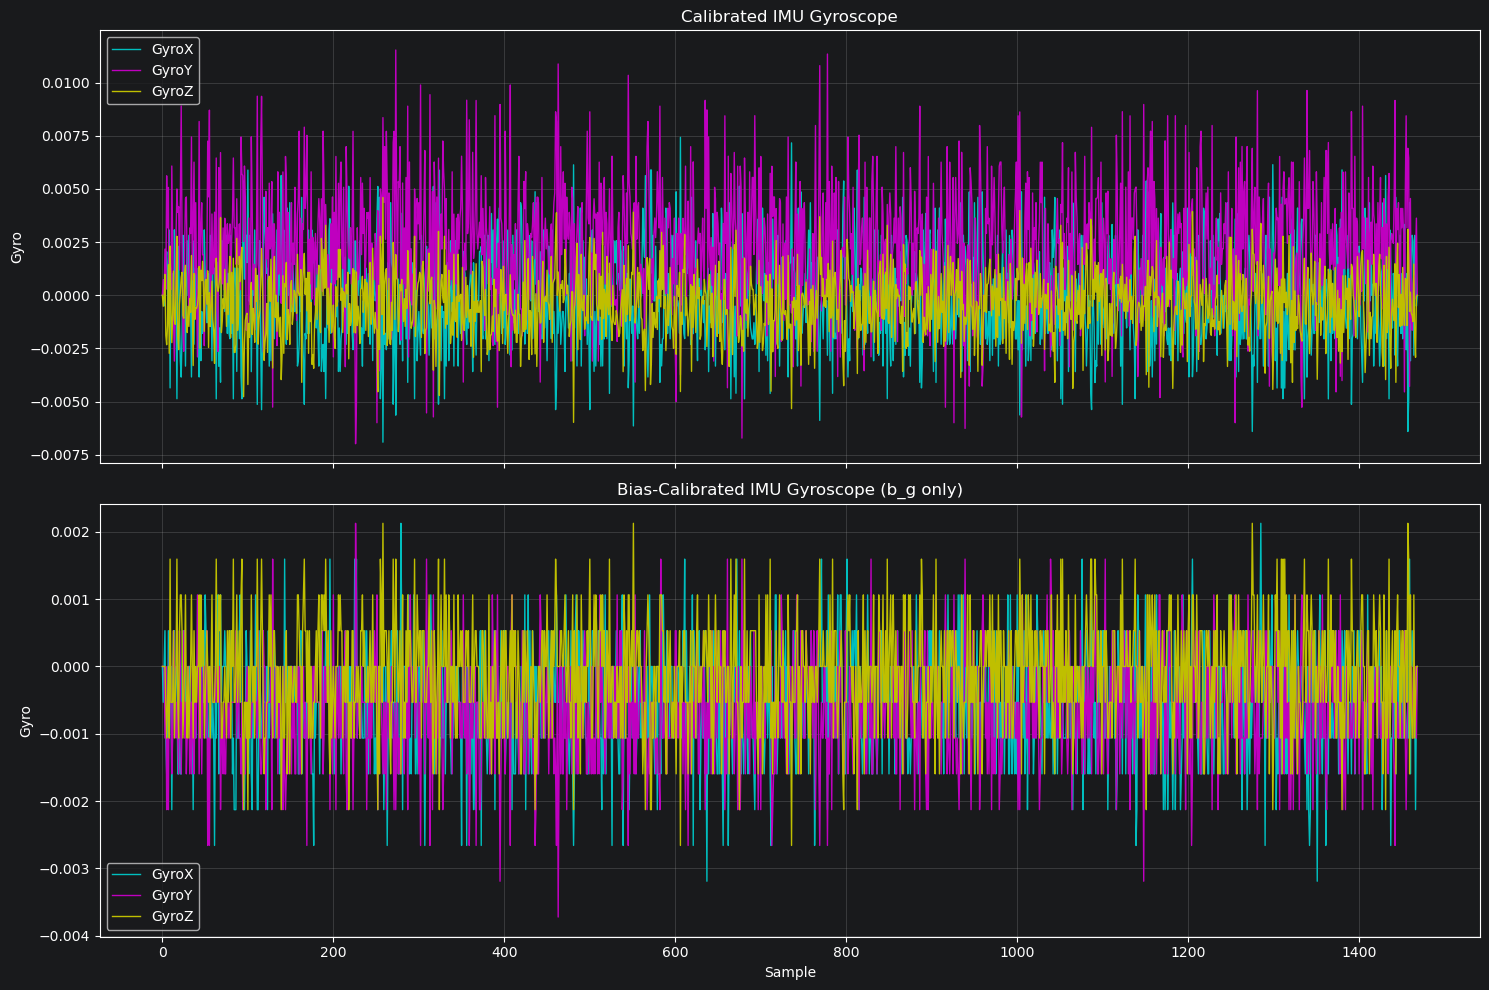

gyro_calibrated_stats:
{'GyroX': {'mean': -2.7767016138379035e-05, 'stddev': 0.0022970055082878}, 'GyroY': {'mean': 0.0023199608242202795, 'stddev': 0.0029368074331292105}, 'GyroZ': {'mean': -0.0004068079966579715, 'stddev': 0.0015190705262674007}}
gyro_bias_calibrated_stats:
{'GyroX': {'mean': -0.0005469638106875426, 'stddev': 0.0008152056364618708}, 'GyroY': {'mean': -0.000659254478216474, 'stddev': 0.0007962204670189535}, 'GyroZ': {'mean': -0.00010069935017018378, 'stddev': 0.0007930984619737528}}


In [12]:
imu_data_gyro_calibrated: list[np.ndarray] = []
imu_data_gyro_bias_calibrated: list[np.ndarray] = []
for data in imu_data_acc_calibrated:
    calibrated = data.copy()
    calibrated[4:7] = gyro_calibrated(data[4:7], T_g, K_g, b_g)
    imu_data_gyro_calibrated.append(calibrated)

    bias_calibrated = data.copy()
    bias_calibrated[4:7] = data[4:7] + b_g
    imu_data_gyro_bias_calibrated.append(bias_calibrated)

all_data_gyro_calibrated = np.hstack(imu_data_gyro_calibrated)
all_data_gyro_bias_calibrated = np.hstack(imu_data_gyro_bias_calibrated)
gyro_calibrated_all = all_data_gyro_calibrated[4:7]
gyro_bias_calibrated_all = all_data_gyro_bias_calibrated[4:7]

gyro_labels = ['GyroX', 'GyroY', 'GyroZ']
colors = ['c', 'm', 'y']

fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
for i in range(3):
    axes[0].plot(gyro_calibrated_all[i], label=gyro_labels[i], color=colors[i], linewidth=1)
    axes[1].plot(gyro_bias_calibrated_all[i], label=gyro_labels[i], color=colors[i], linewidth=1)

axes[0].set_ylabel('Gyro')
axes[0].set_title('Calibrated IMU Gyroscope')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Sample')
axes[1].set_ylabel('Gyro')
axes[1].set_title('Bias-Calibrated IMU Gyroscope (b_g only)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

gyro_calibrated_stats = {
    label: {
        'mean': float(np.mean(gyro_calibrated_all[i])),
        'stddev': float(np.std(gyro_calibrated_all[i])),
    }
    for i, label in enumerate(gyro_labels)
}

gyro_bias_calibrated_stats = {
    label: {
        'mean': float(np.mean(gyro_bias_calibrated_all[i])),
        'stddev': float(np.std(gyro_bias_calibrated_all[i])),
    }
    for i, label in enumerate(gyro_labels)
}

print('gyro_calibrated_stats:')
print(gyro_calibrated_stats)
print('gyro_bias_calibrated_stats:')
print(gyro_bias_calibrated_stats)


In [13]:
from scipy.io import savemat

mat_path = DATASET_DIR / 'params.mat'

savemat(mat_path, {
    'theta_acc': theta_acc.ravel(),
    'theta_gyro': theta_acc.ravel(),
    'T_acc': T,
    'K_acc': K,
    'b_acc': b,
    'T_gyro': T_g,
    'K_gyro': K_g,
    'b_gyro': b_g,
})

print(f'saved: {mat_path.name}')


saved: params.mat
